# Semana 6 — ¿Llega a playoffs? Predicción con datos de la NFL
**Materia:** Aprendizaje Automático — Politécnico  |  **Alumno:** Tomás Roa Gunn

**Pregunta:** mirando solo los primeros 9 partidos de la temporada regular, ¿podemos predecir qué equipos van a jugar playoffs?

- **Datos:** resultados de todos los partidos de la NFL (proyecto abierto *nflverse*), temporadas 2002–2025.
- **Clase positiva:** el equipo juega playoffs.
- **Modelos comparados:** regresión logística, árbol de decisión y KNN, evaluados sobre los mismos equipos de prueba.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
sns.set_theme(style="whitegrid")

## 1. Datos

In [2]:
games = pd.read_csv("../Datos/nfl_games.csv")
games = games[(games.season >= 2002) & (games.season <= 2025)].copy()   # desde 2002: 32 equipos

# Equipos que cambiaron de ciudad: unificamos el nombre
mudanzas = {"OAK": "LV", "SD": "LAC", "STL": "LA"}
games["home_team"] = games.home_team.replace(mudanzas)
games["away_team"] = games.away_team.replace(mudanzas)

print(games.shape)
games[["season", "game_type", "week", "away_team", "away_score", "home_team", "home_score"]].head()

(6499, 46)


,season,game_type,week,away_team,away_score,home_team,home_score
777,2002,REG,1,SF,16.0,NYG,13.0
778,2002,REG,1,NYJ,37.0,BUF,31.0
779,2002,REG,1,BAL,7.0,CAR,10.0
780,2002,REG,1,MIN,23.0,CHI,27.0
781,2002,REG,1,LAC,34.0,CIN,6.0


`game_type` = REG es temporada regular; cualquier otro valor (WC, DIV, CON, SB) es playoffs.

## 2. Armado del dataset: una fila por equipo y temporada
Con los partidos hasta la semana 9 calculamos cómo viene cada equipo. La etiqueta (`playoffs`) sale de saber si ese equipo apareció en algún partido de playoffs esa temporada.

**Cuidado con la fuga de datos:** las características usan solo semanas 1–9. La etiqueta usa lo que pasa después, pero nunca entra como variable.

In [3]:
CORTE = 9
reg = games[games.game_type == "REG"]
playoffs_games = games[games.game_type != "REG"]

mitad = reg[reg.week <= CORTE]
lados = []
for lado, rival in (("home", "away"), ("away", "home")):
    lados.append(pd.DataFrame({
        "season": mitad.season,
        "team": mitad[f"{lado}_team"],
        "pf": mitad[f"{lado}_score"],      # puntos a favor
        "pa": mitad[f"{rival}_score"],     # puntos en contra
    }))
t = pd.concat(lados)
t["victoria"] = (t.pf > t.pa).astype(int)
t["derrota"] = (t.pf < t.pa).astype(int)
t["empate"] = (t.pf == t.pa).astype(int)

df = t.groupby(["season", "team"]).agg(
    juegos=("victoria", "size"), victorias=("victoria", "sum"),
    derrotas=("derrota", "sum"), empates=("empate", "sum"),
    pf=("pf", "sum"), pa=("pa", "sum")).reset_index()

df["pct_victorias"] = (df.victorias + 0.5 * df.empates) / df.juegos
df["pf_por_juego"] = df.pf / df.juegos
df["pa_por_juego"] = df.pa / df.juegos
df["dif_puntos_por_juego"] = df.pf_por_juego - df.pa_por_juego

# Etiqueta: ¿jugó algún partido de playoffs esa temporada?
clasificados = pd.concat([
    playoffs_games[["season", "home_team"]].rename(columns={"home_team": "team"}),
    playoffs_games[["season", "away_team"]].rename(columns={"away_team": "team"}),
]).drop_duplicates()
clasificados["playoffs"] = 1
df = df.merge(clasificados, on=["season", "team"], how="left")
df["playoffs"] = df.playoffs.fillna(0).astype(int)

print(df.shape)
print("Proporción que llega a playoffs:", round(df.playoffs.mean(), 3))
df.head()

(768, 13)
Proporción que llega a playoffs: 0.391


,season,team,juegos,victorias,derrotas,empates,pf,pa,pct_victorias,pf_por_juego,pa_por_juego,dif_puntos_por_juego,playoffs
0,2002,ARI,8,4,4,0,150.0,158.0,0.500000,18.750000,19.750000,-1.000000,0
1,2002,ATL,8,5,3,0,187.0,136.0,0.625000,23.375000,17.000000,6.375000,1
2,2002,BAL,8,3,5,0,139.0,162.0,0.375000,17.375000,20.250000,-2.875000,0
3,2002,BUF,9,5,4,0,248.0,269.0,0.555556,27.555556,29.888889,-2.333333,0
4,2002,CAR,8,3,5,0,111.0,117.0,0.375000,13.875000,14.625000,-0.750000,0


## 3. Exploración rápida

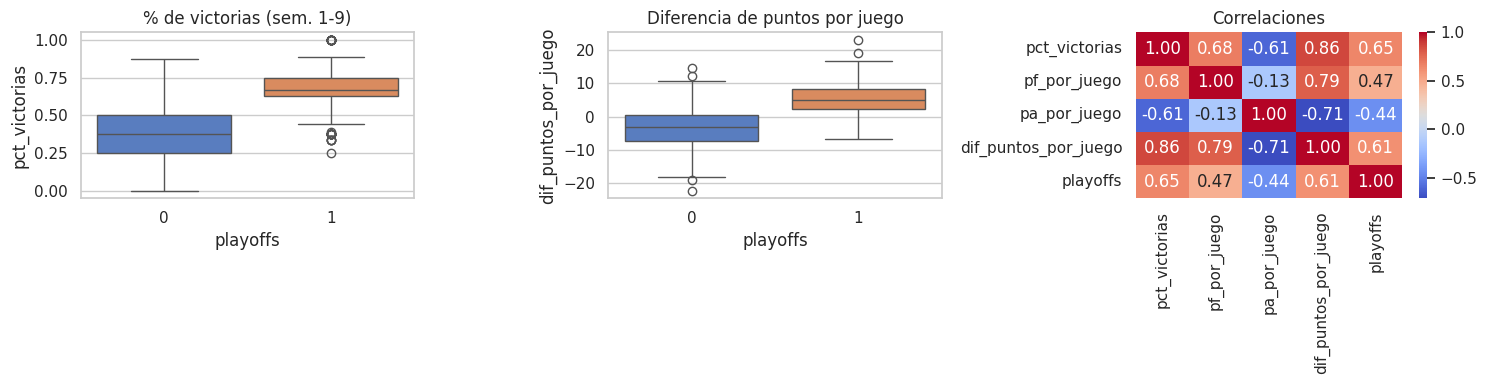

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x="playoffs", y="pct_victorias", ax=axes[0], hue="playoffs", palette="muted", legend=False)
axes[0].set_title("% de victorias (sem. 1-9)")
sns.boxplot(data=df, x="playoffs", y="dif_puntos_por_juego", ax=axes[1], hue="playoffs", palette="muted", legend=False)
axes[1].set_title("Diferencia de puntos por juego")
sns.heatmap(df[["pct_victorias", "pf_por_juego", "pa_por_juego", "dif_puntos_por_juego", "playoffs"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm", ax=axes[2])
axes[2].set_title("Correlaciones")
plt.tight_layout(); plt.show()

**Lectura:** los equipos que llegan a playoffs vienen con más victorias y mejor diferencia de puntos desde la mitad de la temporada. Las dos variables están muy correlacionadas entre sí (ganar más suele significar anotar más y recibir menos), algo a tener en cuenta con la regresión logística.

## 4. Separación entrenamiento / prueba
Como los datos son temporadas, separo **por tiempo**: entreno con 2002–2018 y pruebo con 2019–2025 (años que el modelo nunca vio). Es lo que pasaría en la realidad: predecir una temporada futura con lo aprendido de las pasadas.

In [5]:
VARS = ["pct_victorias", "dif_puntos_por_juego", "pf_por_juego", "pa_por_juego"]
train = df[df.season <= 2018]
test = df[df.season >= 2019]
X_train, y_train = train[VARS], train.playoffs
X_test, y_test = test[VARS], test.playoffs

print("Entrenamiento:", len(train), "| % playoffs:", round(y_train.mean(), 3))
print("Prueba:       ", len(test),  "| % playoffs:", round(y_test.mean(), 3))
print("Exactitud de un modelo que siempre dice 'no llega':", round(1 - y_test.mean(), 3))

Entrenamiento: 544 | % playoffs: 0.375
Prueba:        224 | % playoffs: 0.429
Exactitud de un modelo que siempre dice 'no llega': 0.571


El último número es la línea base: cualquier modelo tiene que superarla para servir de algo.

## 5. Tres modelos con su preprocesamiento
- **Regresión logística y KNN:** necesitan escalar las variables (usan coeficientes y distancias). El escalado va dentro del `Pipeline`, así se ajusta solo con los datos de entrenamiento y no se filtra información de prueba.
- **Árbol:** no necesita escalar.

Los hiperparámetros (regularización `C`, profundidad, número de vecinos `K`) se eligen con validación cruzada de 5 particiones **solo sobre entrenamiento**, optimizando F1.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    "Regresión logística": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                            {"logisticregression__C": [0.01, 0.1, 1, 10]}),
    "Árbol de decisión":   (DecisionTreeClassifier(random_state=42),
                            {"max_depth": [2, 3, 4, 5, 8, None]}),
    "KNN":                 (make_pipeline(StandardScaler(), KNeighborsClassifier()),
                            {"kneighborsclassifier__n_neighbors": [1, 3, 5, 11, 21, 41]}),
}

resultados, ajustados, predicciones = [], {}, {}
for nombre, (modelo, grilla) in modelos.items():
    gs = GridSearchCV(modelo, grilla, cv=cv, scoring="f1").fit(X_train, y_train)
    pred = gs.predict(X_test)
    ajustados[nombre], predicciones[nombre] = gs, pred
    resultados.append({"Modelo": nombre, "Mejor ajuste": gs.best_params_,
                       "F1 (validación)": round(gs.best_score_, 3),
                       "Exactitud": round(accuracy_score(y_test, pred), 3),
                       "Precisión": round(precision_score(y_test, pred), 3),
                       "Recall": round(recall_score(y_test, pred), 3),
                       "F1 (prueba)": round(f1_score(y_test, pred), 3)})
pd.DataFrame(resultados).set_index("Modelo")

,Mejor ajuste,F1 (validación),Exactitud,Precisión,Recall,F1 (prueba)
Modelo,,,,,,
Regresión logística,{'logisticregression__C': 10},0.738,0.817,0.831,0.719,0.771
Árbol de decisión,{'max_depth': 2},0.752,0.812,0.793,0.760,0.777
KNN,{'kneighborsclassifier__n_neighbors': 41},0.747,0.812,0.821,0.719,0.767


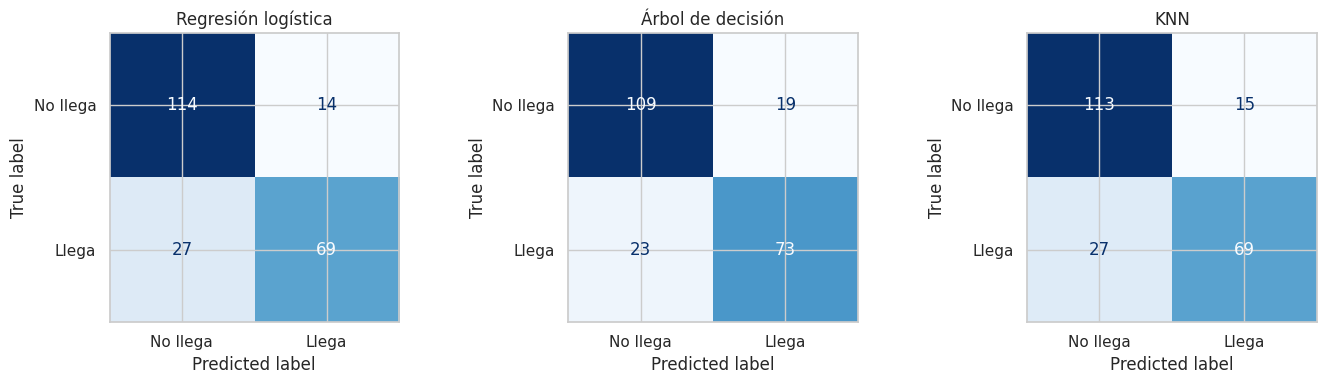

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["No llega", "Llega"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre)
plt.tight_layout(); plt.show()

## 6. Qué aprendió cada modelo

pa_por_juego           -0.31
pf_por_juego            0.29
dif_puntos_por_juego    0.40
pct_victorias           1.65
dtype: float64


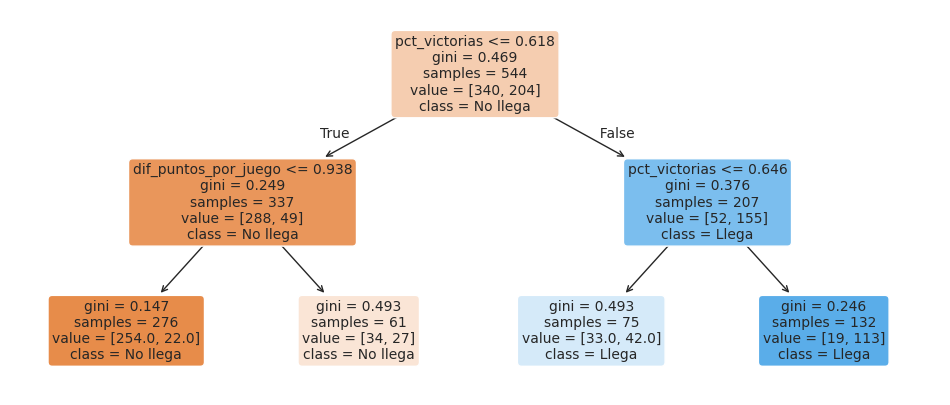

In [8]:
# Coeficientes de la regresión logística (variables ya escaladas)
logit = ajustados["Regresión logística"].best_estimator_.named_steps["logisticregression"]
print(pd.Series(logit.coef_[0], index=VARS).round(2).sort_values())

# Reglas del árbol
arbol = ajustados["Árbol de decisión"].best_estimator_
plt.figure(figsize=(12, 5))
plot_tree(arbol, feature_names=VARS, class_names=["No llega", "Llega"], filled=True, rounded=True, fontsize=10)
plt.show()

## 7. ¿Y si cambiamos el umbral de la regresión logística?
Por defecto el modelo dice "llega" si la probabilidad supera 0.5. Para equipos al borde de la clasificación puede convenir otro umbral. Veamos cómo cambian precisión y recall.

In [9]:
prob = ajustados["Regresión logística"].predict_proba(X_test)[:, 1]
filas = []
for u in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (prob >= u).astype(int)
    filas.append({"Umbral": u, "Precisión": round(precision_score(y_test, p), 3),
                  "Recall": round(recall_score(y_test, p), 3), "F1": round(f1_score(y_test, p), 3)})
pd.DataFrame(filas).set_index("Umbral")

,Precisión,Recall,F1
Umbral,,,
0.3,0.741,0.865,0.798
0.4,0.750,0.781,0.765
0.5,0.831,0.719,0.771
0.6,0.840,0.656,0.737
0.7,0.902,0.573,0.701


## 8. Conclusiones

**1. Los tres modelos empatan.** Sobre 224 equipos de prueba (2019–2025) los tres aciertan cerca del 81 % y tienen un F1 de 0.77, contra 57 % de un modelo que siempre dijera "no llega". Las diferencias entre ellos equivalen a unos pocos equipos, así que no puedo decir que uno sea realmente mejor que otro.

**2. Lo que importa es el récord.** El árbol, con profundidad 2, terminó aplicando prácticamente una sola regla: *más de 62 % de victorias* (por ejemplo, 5 ganados de 8) → llega a playoffs. En la regresión logística, `pct_victorias` pesa mucho más que cualquier otra variable. Los puntos a favor y en contra agregan poco una vez que ya conocemos las victorias.

**3. Elección de modelo.** Si tuviera que quedarme con uno, sería el **árbol de profundidad 2**: rinde igual que los otros, es el más fácil de explicar y tiene el mejor recall (0.76) del grupo. La regresión logística es la alternativa si se quiere una probabilidad por equipo, y permite ajustar el umbral. KNN eligió K = 41, el valor más alto de la grilla, lo que sugiere que su mejor versión es casi un promedio general; no aporta nada extra y es el menos interpretable.

**4. Umbral.** Bajar el umbral de la regresión logística a 0.3 sube el recall a 0.87 (detecta más clasificados) a costa de precisión (0.74). Subirlo a 0.7 hace lo contrario. Cuál conviene depende de qué error preocupe más: no detectar a un equipo que sí clasifica, o marcar a uno que no.

**5. Limitaciones.**
- Hay un techo natural: en 9 partidos queda mucha temporada por jugar (lesiones, fixture, suerte), así que el 81 % no es sorprendente ni se va a poder mejorar mucho con estas variables.
- Las variables usan solo resultados. No incluyen calidad del quarterback, lesiones ni dificultad del calendario restante.
- Hubo un cambio de formato (de 12 a 14 equipos clasificados desde 2020), que el modelo no conoce.
- Son 768 filas en total, un dataset chico: los resultados pueden cambiar bastante si se elige otra partición.

**Posibles mejoras:** agregar la dificultad del calendario que queda, usar los últimos 4 partidos como medida de racha, o probar un corte distinto (semana 6 o semana 12) para ver cómo cambia la precisión a medida que avanza la temporada.
